In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import requests
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit


In [2]:
!pip install --upgrade yfinance --no-cache-dir

In [5]:
# HYPERPARAMETERS
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TICKER = 'MSFT'
START_DATE = '2020-01-01'
FEATURE_COLS = ['log_return', 'SMA_14', 'SMA_50', 'RSI_14', 'MACD', 'MACD_signal',
                 'BB_upper', 'BB_lower', 'Volume']
TARGET_COL = 'log_return'


TRAIN_RATIO = 0.70
VAL_RATIO = 0.10


SEQ_LENGTH = 90   
HORIZON = 30      

# First model: LSTM
SEQ2SEQ_HIDDEN_DIM = 128
SEQ2SEQ_NUM_LAYERS = 2
SEQ2SEQ_DROPOUT = 0.3
SEQ2SEQ_NUM_HEADS = 4
SEQ2SEQ_LR = 1e-3
SEQ2SEQ_EPOCHS = 200
SEQ2SEQ_SCHEDULER_FACTOR = 0.5
SEQ2SEQ_SCHEDULER_PATIENCE = 10
CKPT_SEQ2SEQ = 'best_seq2seq.pth'

# Second model: TimeGAN
TIMEGAN_HIDDEN_DIM = 32
TIMEGAN_NUM_LAYERS = 2
TIMEGAN_DROPOUT = 0.1
TIMEGAN_LR = 1e-3
TIMEGAN_EPOCHS_AUTOENCODER = 100
TIMEGAN_EPOCHS_SUPERVISED = 100
TIMEGAN_EPOCHS_JOINT = 500
TIMEGAN_GAMMA_SUPERVISED = 100.0
TIMEGAN_ETA_MOMENTS = 100.0
TIMEGAN_D_LOSS_THRESHOLD = 0.20
CKPT_TIMEGAN_AE = 'best_timegan_ae.pth'
CKPT_TIMEGAN_SUPERVISED = 'best_timegan_supervised.pth'
CKPT_TIMEGAN_JOINT = 'best_timegan_joint.pth'

# Third model: Conditional Normalizing Flow
FLOW_CONTEXT_DIM = 64
FLOW_HIDDEN_DIM = 64
FLOW_NUM_FLOWS = 8
FLOW_ENCODER_LAYERS = 2
FLOW_ENCODER_DROPOUT = 0.1
FLOW_LR = 1e-3
FLOW_EPOCHS = 200
FLOW_GRAD_CLIP = 5.0
FLOW_NUM_SAMPLES_DEMO = 1000
FLOW_NUM_SAMPLES_BACKTEST = 200
CKPT_FLOW = 'best_flow.pth'


BACKTEST_N_SPLITS = 5

In [6]:
def download_price_data(ticker, start):
    file_path = f"{ticker}_raw_data.csv"
    
    if os.path.exists(file_path):
        print(f"File found: '{file_path}'")
        
        sample = pd.read_csv(file_path, nrows=2)
        
        if sample.iloc[0, 0] == 'Ticker' or 'Ticker' in sample.columns:
            data = pd.read_csv(file_path, header=[0, 1], index_col=0, parse_dates=True)
            data.columns = data.columns.get_level_values(0)
        else:
            data = pd.read_csv(file_path, index_col=0, parse_dates=True)
            
        data.index.name = 'Date'
        return data

    print(f"File '{file_path}' not found.")
    session = requests.Session()
    session.headers.update({
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                      '(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    })
    data = yf.download(ticker, start=start, session=session)
    
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
        
    data.to_csv(file_path)
    print("Download completed")
    
    return data


def add_technical_features(data):
    out = data.copy()

    out['log_return'] = np.log(out['Close'] / out['Close'].shift(1))
    out['SMA_14'] = out['Close'].rolling(window=14).mean()
    out['SMA_50'] = out['Close'].rolling(window=50).mean()

    delta = out['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    out['RSI_14'] = 100 - (100 / (1 + avg_gain / avg_loss))

    ema_fast = out['Close'].ewm(span=12, adjust=False).mean()
    ema_slow = out['Close'].ewm(span=26, adjust=False).mean()
    out['MACD'] = ema_fast - ema_slow
    out['MACD_signal'] = out['MACD'].ewm(span=9, adjust=False).mean()

    bb_sma = out['Close'].rolling(window=20).mean()
    bb_std = out['Close'].rolling(window=20).std()
    out['BB_upper'] = bb_sma + 2 * bb_std
    out['BB_lower'] = bb_sma - 2 * bb_std

    return out.dropna().reset_index(drop=False)

raw_df = download_price_data(TICKER, START_DATE)
df = add_technical_features(raw_df)

File found: 'MSFT_raw_data.csv'


In [7]:
n = len(df)
train_end = int(n * TRAIN_RATIO)
val_end = train_end + int(n * VAL_RATIO)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

scalers = {}
train_scaled = pd.DataFrame(index=train_df.index)
val_scaled = pd.DataFrame(index=val_df.index)
test_scaled = pd.DataFrame(index=test_df.index)

for col in FEATURE_COLS:
    scaler = StandardScaler()
    train_scaled[col] = scaler.fit_transform(train_df[[col]]).flatten()
    val_scaled[col] = scaler.transform(val_df[[col]]).flatten()
    test_scaled[col] = scaler.transform(test_df[[col]]).flatten()
    scalers[col] = scaler

target_scaler = scalers[TARGET_COL]
target_idx = FEATURE_COLS.index(TARGET_COL)
num_features = len(FEATURE_COLS)

In [8]:
def create_sequences(data, target_idx, seq_length, horizon):
    X, y = [], []
    for i in range(len(data) - seq_length - horizon + 1):
        X.append(data[i:i + seq_length, :])
        y.append(data[i + seq_length:i + seq_length + horizon, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def to_tensor(array):
    return torch.from_numpy(array).type(torch.Tensor).to(DEVICE)


X_train_np, y_train_np = create_sequences(train_scaled[FEATURE_COLS].values, target_idx, SEQ_LENGTH, HORIZON)
X_val_np, y_val_np = create_sequences(val_scaled[FEATURE_COLS].values, target_idx, SEQ_LENGTH, HORIZON)
X_test_np, y_test_np = create_sequences(test_scaled[FEATURE_COLS].values, target_idx, SEQ_LENGTH, HORIZON)

X_train, y_train_scaled = to_tensor(X_train_np), to_tensor(y_train_np)
X_val, y_val_scaled = to_tensor(X_val_np), to_tensor(y_val_np)
X_test, y_test_scaled = to_tensor(X_test_np), to_tensor(y_test_np)

val_dates = val_df['Date'].values[SEQ_LENGTH: SEQ_LENGTH + len(y_val_np)]
test_dates = test_df['Date'].values[SEQ_LENGTH: SEQ_LENGTH + len(y_test_np)]


def inverse_target(scaled_array, horizon):
    flat = scaled_array.reshape(-1, 1)
    return target_scaler.inverse_transform(flat).reshape(-1, horizon)

In [9]:


# LSTM

class PredictionModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout=0.2, num_heads=4):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                             dropout=dropout if num_layers > 1 else 0.0)
        self.post_lstm_dropout = nn.Dropout(dropout)
        self.self_attention = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads,
                                                      dropout=dropout, batch_first=True)
        self.post_attention_dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=DEVICE)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=DEVICE)

        lstm_out, _ = self.lstm(x, (h0.detach(), c0.detach()))
        lstm_out = self.post_lstm_dropout(lstm_out)

        attn_out, _ = self.self_attention(lstm_out, lstm_out, lstm_out)
        attn_out = self.post_attention_dropout(attn_out)

        return self.fc(attn_out[:, -1, :])


# TimeGAN

class Embedder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=2, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x):
        out, h_n = self.gru(x)
        return torch.sigmoid(self.fc(out)), h_n


class Recovery(nn.Module):
    def __init__(self, hidden_dim, output_dim, num_layers=2, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(hidden_dim, hidden_dim, num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, H):
        out, _ = self.gru(H)
        return self.fc(out)


class Generator(nn.Module):
    
    def __init__(self, hidden_dim, num_layers=2, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.gru = nn.GRU(hidden_dim, hidden_dim, num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, Z_or_H, h0=None):
        out, h_n = self.gru(Z_or_H, h0)
        return torch.sigmoid(self.fc(out)), h_n


class Discriminator(nn.Module):
    def __init__(self, hidden_dim, num_layers=1, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(hidden_dim, hidden_dim, num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, H):
        out, _ = self.gru(H)
        return self.fc(out)


# MAF

class MaskedLinear(nn.Module):
    def __init__(self, in_features, out_features, mask):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.register_buffer('mask', mask)

    def forward(self, x):
        return nn.functional.linear(x, self.linear.weight * self.mask, self.linear.bias)


def _build_made_masks(input_dim, hidden_dim):
    input_degrees = torch.arange(1, input_dim + 1)
    hidden_degrees = torch.arange(hidden_dim) % max(1, input_dim - 1) + 1
    mask_hidden = (hidden_degrees.unsqueeze(-1) >= input_degrees.unsqueeze(0)).float()
    mask_out_single = (input_degrees.unsqueeze(-1) > hidden_degrees.unsqueeze(0)).float()
    mask_output = torch.cat([mask_out_single, mask_out_single], dim=0)
    return mask_hidden, mask_output


class MADE(nn.Module):
    def __init__(self, input_dim, hidden_dim, context_dim):
        super().__init__()
        mask_hidden, mask_output = _build_made_masks(input_dim, hidden_dim)
        self.input_layer = MaskedLinear(input_dim, hidden_dim, mask_hidden)
        self.context_proj = nn.Linear(context_dim, hidden_dim)
        self.hidden_layer = nn.Linear(hidden_dim, hidden_dim)
        self.output_layer = MaskedLinear(hidden_dim, 2 * input_dim, mask_output)
        self.activation = nn.ReLU()

    def forward(self, y, context):
        h = self.activation(self.input_layer(y) + self.context_proj(context))
        h = self.activation(self.hidden_layer(h))
        mu, log_sigma = self.output_layer(h).chunk(2, dim=-1)
        log_sigma = torch.clamp(log_sigma, min=-5.0, max=3.0)
        return mu, log_sigma


class MAFLayer(nn.Module):
    def __init__(self, input_dim, hidden_dim, context_dim, reverse=False):
        super().__init__()
        self.made = MADE(input_dim, hidden_dim, context_dim)
        self.reverse = reverse

    def forward(self, y, context):
        mu, log_sigma = self.made(y, context)
        u = (y - mu) * torch.exp(-log_sigma)
        log_det = -log_sigma.sum(dim=-1)
        if self.reverse:
            u = u.flip(dims=[-1])
        return u, log_det

    def inverse(self, u, context):
        if self.reverse:
            u = u.flip(dims=[-1])
        y = torch.zeros_like(u)
        for t in range(u.size(-1)):
            mu, log_sigma = self.made(y, context)
            y[..., t] = u[..., t] * torch.exp(log_sigma[..., t]) + mu[..., t]
        return y


class ConditionalMAF(nn.Module):
    def __init__(self, horizon, num_features, context_dim=32, flow_hidden_dim=64,
                 num_flows=4, encoder_num_layers=2, encoder_dropout=0.1):
        super().__init__()
        self.horizon = horizon
        self.context_dim = context_dim
        self.encoder = nn.GRU(num_features, context_dim, encoder_num_layers, batch_first=True,
                               dropout=encoder_dropout if encoder_num_layers > 1 else 0.0)
        self.flows = nn.ModuleList([
            MAFLayer(horizon, flow_hidden_dim, context_dim, reverse=(i % 2 == 1))
            for i in range(num_flows)
        ])
        self.register_buffer('base_mean', torch.zeros(horizon))
        self.register_buffer('base_std', torch.ones(horizon))

    def encode_context(self, x_history):
        _, h_n = self.encoder(x_history)
        return h_n[-1]

    def log_prob(self, y, x_history):
        context = self.encode_context(x_history)
        u = y
        log_det_total = torch.zeros(y.size(0), device=y.device)
        for flow in self.flows:
            u, log_det = flow(u, context)
            log_det_total = log_det_total + log_det
        base_dist = torch.distributions.Normal(self.base_mean, self.base_std)
        return base_dist.log_prob(u).sum(dim=-1) + log_det_total

    def nll_loss(self, y, x_history):
        return -self.log_prob(y, x_history).mean()

    @torch.no_grad()
    def sample(self, x_history, num_samples=1000):
        self.eval()
        context = self.encode_context(x_history)
        batch_size = x_history.size(0)
        context_rep = context.unsqueeze(1).expand(-1, num_samples, -1).reshape(batch_size * num_samples, self.context_dim)

        base_dist = torch.distributions.Normal(self.base_mean, self.base_std)
        u = base_dist.sample((batch_size * num_samples,))

        y = u
        for flow in reversed(self.flows):
            y = flow.inverse(y, context_rep)
        y = y.reshape(batch_size, num_samples, self.horizon)

        return {
            'samples': y,
            'median': y.median(dim=1).values,
            'lower_5': torch.quantile(y, 0.05, dim=1),
            'upper_95': torch.quantile(y, 0.95, dim=1),
        }

In [10]:
# Metrics

def dtw_distance(seq_a, seq_b):
    n, m = len(seq_a), len(seq_b)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(seq_a[i - 1] - seq_b[j - 1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i - 1, j], dtw_matrix[i, j - 1], dtw_matrix[i - 1, j - 1])
    return dtw_matrix[n, m]


def dtw_batch_mean(y_true_batch, y_pred_batch):
    return np.mean([dtw_distance(y_true_batch[i], y_pred_batch[i]) for i in range(len(y_true_batch))])


def crps_empirical(samples, y_true):
    N = samples.shape[-1]
    samples_sorted = np.sort(samples, axis=-1)
    weights = (2 * np.arange(1, N + 1) - N - 1)
    term1 = np.mean(np.abs(samples - y_true[..., None]), axis=-1)
    term2 = np.sum(weights * samples_sorted, axis=-1) / (N ** 2)
    return term1 - term2


def reconstruct_prices(log_return_path, base_price):
    return base_price * np.exp(np.cumsum(log_return_path, axis=-1))


def save_checkpoint(state_dicts, path):
    torch.save(state_dicts, path)


def load_checkpoint(path):
    return torch.load(path, map_location=DEVICE)

In [11]:
# Training LSTM

model = PredictionModel(
    input_dim=num_features, hidden_dim=SEQ2SEQ_HIDDEN_DIM, num_layers=SEQ2SEQ_NUM_LAYERS,
    output_dim=HORIZON, dropout=SEQ2SEQ_DROPOUT, num_heads=SEQ2SEQ_NUM_HEADS
).to(DEVICE)

criterion = nn.HuberLoss(delta=1.0)
optimizer = optim.Adam(model.parameters(), lr=SEQ2SEQ_LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=SEQ2SEQ_SCHEDULER_FACTOR, patience=SEQ2SEQ_SCHEDULER_PATIENCE
)

best_val_loss = float('inf')

for epoch in range(SEQ2SEQ_EPOCHS):
    model.train()
    train_pred = model(X_train)
    train_loss = criterion(train_pred, y_train_scaled)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val_scaled)

    scheduler.step(val_loss)

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        save_checkpoint(model.state_dict(), CKPT_SEQ2SEQ)

    if epoch % 25 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"[Seq2Seq-Attention] Epoch {epoch:3d} | Train Loss {train_loss.item():.6f} | "
              f"Val Loss {val_loss.item():.6f} | Best Val {best_val_loss:.6f} | LR {current_lr:.6f}")

model.load_state_dict(load_checkpoint(CKPT_SEQ2SEQ))
model.eval()
print(f"[Seq2Seq-Attention] Training completed. Best Val Loss: {best_val_loss:.6f}")

[Seq2Seq-Attention] Epoch   0 | Train Loss 0.334130 | Val Loss 0.300203 | Best Val 0.300203 | LR 0.001000
[Seq2Seq-Attention] Epoch  25 | Train Loss 0.332494 | Val Loss 0.307519 | Best Val 0.297257 | LR 0.000500
[Seq2Seq-Attention] Epoch  50 | Train Loss 0.332112 | Val Loss 0.320815 | Best Val 0.297257 | LR 0.000125
[Seq2Seq-Attention] Epoch  75 | Train Loss 0.331850 | Val Loss 0.320841 | Best Val 0.297257 | LR 0.000031
[Seq2Seq-Attention] Epoch 100 | Train Loss 0.331805 | Val Loss 0.321377 | Best Val 0.297257 | LR 0.000008
[Seq2Seq-Attention] Epoch 125 | Train Loss 0.331780 | Val Loss 0.321506 | Best Val 0.297257 | LR 0.000001
[Seq2Seq-Attention] Epoch 150 | Train Loss 0.331879 | Val Loss 0.321520 | Best Val 0.297257 | LR 0.000000
[Seq2Seq-Attention] Epoch 175 | Train Loss 0.331845 | Val Loss 0.321522 | Best Val 0.297257 | LR 0.000000
[Seq2Seq-Attention] Training completed. Best Val Loss: 0.297257


C:\Users\Utente\AppData\Local\Temp\ipykernel_11668\179205473.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=DEVICE)


In [12]:
# Training TimeGAN
embedder = Embedder(num_features, TIMEGAN_HIDDEN_DIM, TIMEGAN_NUM_LAYERS, TIMEGAN_DROPOUT).to(DEVICE)
recovery = Recovery(TIMEGAN_HIDDEN_DIM, num_features, TIMEGAN_NUM_LAYERS, TIMEGAN_DROPOUT).to(DEVICE)
generator = Generator(TIMEGAN_HIDDEN_DIM, TIMEGAN_NUM_LAYERS, TIMEGAN_DROPOUT).to(DEVICE)
discriminator = Discriminator(TIMEGAN_HIDDEN_DIM, num_layers=1, dropout=TIMEGAN_DROPOUT).to(DEVICE)

opt_er = optim.Adam(list(embedder.parameters()) + list(recovery.parameters()), lr=TIMEGAN_LR)
opt_g = optim.Adam(generator.parameters(), lr=TIMEGAN_LR)
opt_d = optim.Adam(discriminator.parameters(), lr=TIMEGAN_LR)

mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

In [13]:
# Pretraining Embedder and Recovery
best_val_recon = float('inf')

for epoch in range(TIMEGAN_EPOCHS_AUTOENCODER):
    embedder.train(); recovery.train()

    H, _ = embedder(X_train)
    X_tilde = recovery(H)
    train_recon = mse_loss(X_tilde, X_train)

    opt_er.zero_grad()
    train_recon.backward()
    opt_er.step()

    embedder.eval(); recovery.eval()
    with torch.no_grad():
        H_val, _ = embedder(X_val)
        val_recon = mse_loss(recovery(H_val), X_val)

    if val_recon.item() < best_val_recon:
        best_val_recon = val_recon.item()
        save_checkpoint({'embedder': embedder.state_dict(), 'recovery': recovery.state_dict()}, CKPT_TIMEGAN_AE)

    if epoch % 20 == 0:
        print(f"[TimeGAN - Fase 1/Autoencoder] Epoch {epoch:3d} | Train Loss {train_recon.item():.6f} | "
              f"Val Loss {val_recon.item():.6f} | Best Val {best_val_recon:.6f}")

ckpt = load_checkpoint(CKPT_TIMEGAN_AE)
embedder.load_state_dict(ckpt['embedder'])
recovery.load_state_dict(ckpt['recovery'])
print(f"[TimeGAN - 1] completated. Best Val Reconstruction Loss: {best_val_recon:.6f}")

[TimeGAN - Fase 1/Autoencoder] Epoch   0 | Train Loss 0.817849 | Val Loss 2.241855 | Best Val 2.241855
[TimeGAN - Fase 1/Autoencoder] Epoch  20 | Train Loss 0.738293 | Val Loss 2.150993 | Best Val 2.150993
[TimeGAN - Fase 1/Autoencoder] Epoch  40 | Train Loss 0.497578 | Val Loss 1.294049 | Best Val 1.294049
[TimeGAN - Fase 1/Autoencoder] Epoch  60 | Train Loss 0.301888 | Val Loss 0.588418 | Best Val 0.588418
[TimeGAN - Fase 1/Autoencoder] Epoch  80 | Train Loss 0.262684 | Val Loss 0.512605 | Best Val 0.500217
[TimeGAN - 1] completated. Best Val Reconstruction Loss: 0.399865


C:\Users\Utente\AppData\Local\Temp\ipykernel_11668\179205473.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=DEVICE)


In [14]:
# Supervised pretraining
best_val_supervised = float('inf')

for epoch in range(TIMEGAN_EPOCHS_SUPERVISED):
    generator.train()

    with torch.no_grad():
        H, _ = embedder(X_train)
    H_hat_supervise, _ = generator(H)
    train_supervised = mse_loss(H_hat_supervise[:, :-1, :], H[:, 1:, :])

    opt_g.zero_grad()
    train_supervised.backward()
    opt_g.step()

    generator.eval()
    with torch.no_grad():
        H_val, _ = embedder(X_val)
        H_hat_val, _ = generator(H_val)
        val_supervised = mse_loss(H_hat_val[:, :-1, :], H_val[:, 1:, :])

    if val_supervised.item() < best_val_supervised:
        best_val_supervised = val_supervised.item()
        save_checkpoint({'generator': generator.state_dict()}, CKPT_TIMEGAN_SUPERVISED)

    if epoch % 20 == 0:
        print(f"[TimeGAN - Fase 2/Supervised] Epoch {epoch:3d} | Train Loss {train_supervised.item():.6f} | "
              f"Val Loss {val_supervised.item():.6f} | Best Val {best_val_supervised:.6f}")

generator.load_state_dict(load_checkpoint(CKPT_TIMEGAN_SUPERVISED)['generator'])
print(f"[TimeGAN - 2] completated. Best Val Supervised Loss: {best_val_supervised:.6f}")

[TimeGAN - Fase 2/Supervised] Epoch   0 | Train Loss 0.027494 | Val Loss 0.038953 | Best Val 0.038953
[TimeGAN - Fase 2/Supervised] Epoch  20 | Train Loss 0.020725 | Val Loss 0.039798 | Best Val 0.038953
[TimeGAN - Fase 2/Supervised] Epoch  40 | Train Loss 0.009643 | Val Loss 0.010836 | Best Val 0.010836
[TimeGAN - Fase 2/Supervised] Epoch  60 | Train Loss 0.004095 | Val Loss 0.004321 | Best Val 0.004321
[TimeGAN - Fase 2/Supervised] Epoch  80 | Train Loss 0.002799 | Val Loss 0.002957 | Best Val 0.002957
[TimeGAN - 2] completated. Best Val Supervised Loss: 0.002293


C:\Users\Utente\AppData\Local\Temp\ipykernel_11668\179205473.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=DEVICE)


In [15]:
# Adversarial training
best_val_combined = float('inf')

for epoch in range(TIMEGAN_EPOCHS_JOINT):
    embedder.train(); recovery.train(); generator.train(); discriminator.train()

    Z = torch.rand(X_train.size(0), SEQ_LENGTH, TIMEGAN_HIDDEN_DIM, device=DEVICE)

    # Generator
    H, _ = embedder(X_train)
    H_hat, _ = generator(Z)
    H_hat_supervise, _ = generator(H)
    X_hat = recovery(H_hat)

    Y_fake = discriminator(H_hat)
    loss_g_adv = bce_loss(Y_fake, torch.ones_like(Y_fake))
    loss_g_supervised = mse_loss(H_hat_supervise[:, :-1, :], H[:, 1:, :])
    loss_g_moments = torch.mean(torch.abs(torch.std(X_hat, dim=0) - torch.std(X_train, dim=0))) + \
                      torch.mean(torch.abs(torch.mean(X_hat, dim=0) - torch.mean(X_train, dim=0)))
    loss_g = loss_g_adv + TIMEGAN_GAMMA_SUPERVISED * torch.sqrt(loss_g_supervised) + TIMEGAN_ETA_MOMENTS * loss_g_moments

    opt_g.zero_grad()
    loss_g.backward()
    opt_g.step()

    # Embedder + Recovery
    H, _ = embedder(X_train)
    X_tilde = recovery(H)
    H_hat_supervise, _ = generator(H)
    loss_recon = mse_loss(X_tilde, X_train)
    loss_supervised_er = mse_loss(H_hat_supervise[:, :-1, :], H[:, 1:, :])
    loss_er = 10.0 * torch.sqrt(loss_recon) + 0.1 * loss_supervised_er

    opt_er.zero_grad()
    loss_er.backward()
    opt_er.step()

    # Discriminator 
    with torch.no_grad():
        H, _ = embedder(X_train)
        H_hat, _ = generator(Z)
    Y_real = discriminator(H)
    Y_fake = discriminator(H_hat)
    loss_d = bce_loss(Y_real, torch.ones_like(Y_real)) + bce_loss(Y_fake, torch.zeros_like(Y_fake))

    if loss_d.item() > TIMEGAN_D_LOSS_THRESHOLD:
        opt_d.zero_grad()
        loss_d.backward()
        opt_d.step()

    # Validation
    embedder.eval(); recovery.eval(); generator.eval()
    with torch.no_grad():
        H_val, _ = embedder(X_val)
        val_recon = mse_loss(recovery(H_val), X_val)
        H_hat_val, _ = generator(H_val)
        val_supervised = mse_loss(H_hat_val[:, :-1, :], H_val[:, 1:, :])
        val_combined = val_recon.item() + val_supervised.item()

    if val_combined < best_val_combined:
        best_val_combined = val_combined
        save_checkpoint({
            'embedder': embedder.state_dict(), 'recovery': recovery.state_dict(),
            'generator': generator.state_dict(), 'discriminator': discriminator.state_dict(),
        }, CKPT_TIMEGAN_JOINT)

    if epoch % 20 == 0:
        print(f"[TimeGAN - Fase 3/Adversarial] Epoch {epoch:3d} | loss_g {loss_g.item():.4f} | "
              f"loss_d {loss_d.item():.4f} | Val Combined {val_combined:.6f} | Best Val {best_val_combined:.6f}")

ckpt = load_checkpoint(CKPT_TIMEGAN_JOINT)
embedder.load_state_dict(ckpt['embedder'])
recovery.load_state_dict(ckpt['recovery'])
generator.load_state_dict(ckpt['generator'])
discriminator.load_state_dict(ckpt['discriminator'])
print(f"[TimeGAN - 3] completated. Best Val Combined Loss: {best_val_combined:.6f}")

[TimeGAN - Fase 3/Adversarial] Epoch   0 | loss_g 101.3542 | loss_d 1.3904 | Val Combined 0.403491 | Best Val 0.403491
[TimeGAN - Fase 3/Adversarial] Epoch  20 | loss_g 66.4993 | loss_d 1.3858 | Val Combined 0.240168 | Best Val 0.240168
[TimeGAN - Fase 3/Adversarial] Epoch  40 | loss_g 41.5287 | loss_d 1.3829 | Val Combined 0.173961 | Best Val 0.173961
[TimeGAN - Fase 3/Adversarial] Epoch  60 | loss_g 39.3869 | loss_d 1.3544 | Val Combined 0.149412 | Best Val 0.149412
[TimeGAN - Fase 3/Adversarial] Epoch  80 | loss_g 33.2906 | loss_d 0.8174 | Val Combined 0.146292 | Best Val 0.146292
[TimeGAN - Fase 3/Adversarial] Epoch 100 | loss_g 30.7783 | loss_d 0.4817 | Val Combined 0.157437 | Best Val 0.146292
[TimeGAN - Fase 3/Adversarial] Epoch 120 | loss_g 36.6800 | loss_d 0.5515 | Val Combined 0.155373 | Best Val 0.146292
[TimeGAN - Fase 3/Adversarial] Epoch 140 | loss_g 33.7284 | loss_d 0.4908 | Val Combined 0.135906 | Best Val 0.135906
[TimeGAN - Fase 3/Adversarial] Epoch 160 | loss_g 31.04

C:\Users\Utente\AppData\Local\Temp\ipykernel_11668\179205473.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=DEVICE)


In [16]:
# Training MAF

flow_model = ConditionalMAF(
    horizon=HORIZON, num_features=num_features, context_dim=FLOW_CONTEXT_DIM,
    flow_hidden_dim=FLOW_HIDDEN_DIM, num_flows=FLOW_NUM_FLOWS,
    encoder_num_layers=FLOW_ENCODER_LAYERS, encoder_dropout=FLOW_ENCODER_DROPOUT
).to(DEVICE)

optimizer_flow = optim.Adam(flow_model.parameters(), lr=FLOW_LR)

best_val_nll = float('inf')

for epoch in range(FLOW_EPOCHS):
    flow_model.train()
    train_nll = flow_model.nll_loss(y_train_scaled, X_train)

    optimizer_flow.zero_grad()
    train_nll.backward()
    torch.nn.utils.clip_grad_norm_(flow_model.parameters(), max_norm=FLOW_GRAD_CLIP)
    optimizer_flow.step()

    flow_model.eval()
    with torch.no_grad():
        val_nll = flow_model.nll_loss(y_val_scaled, X_val)

    if val_nll.item() < best_val_nll:
        best_val_nll = val_nll.item()
        save_checkpoint(flow_model.state_dict(), CKPT_FLOW)

    if epoch % 25 == 0:
        print(f"[Normalizing Flow] Epoch {epoch:3d} | Train NLL {train_nll.item():.4f} | "
              f"Val NLL {val_nll.item():.4f} | Best Val {best_val_nll:.4f}")

flow_model.load_state_dict(load_checkpoint(CKPT_FLOW))
flow_model.eval()
print(f"[Normalizing Flow] Training completed. Best Val NLL: {best_val_nll:.4f}")

[Normalizing Flow] Epoch   0 | Train NLL 42.4831 | Val NLL 41.0133 | Best Val 41.0133
[Normalizing Flow] Epoch  25 | Train NLL 32.5246 | Val NLL 34.7373 | Best Val 34.7373
[Normalizing Flow] Epoch  50 | Train NLL 8.3981 | Val NLL 11.4246 | Best Val 11.4246
[Normalizing Flow] Epoch  75 | Train NLL -3.2896 | Val NLL 0.7281 | Best Val 0.7281
[Normalizing Flow] Epoch 100 | Train NLL -11.9652 | Val NLL -6.8148 | Best Val -7.7667
[Normalizing Flow] Epoch 125 | Train NLL -18.4656 | Val NLL -11.5838 | Best Val -13.0278
[Normalizing Flow] Epoch 150 | Train NLL -20.5976 | Val NLL -16.6889 | Best Val -17.2624
[Normalizing Flow] Epoch 175 | Train NLL -25.2124 | Val NLL -16.9679 | Best Val -19.8805
[Normalizing Flow] Training completed. Best Val NLL: -26.1907


C:\Users\Utente\AppData\Local\Temp\ipykernel_11668\179205473.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location=DEVICE)


In [17]:
# Final dashboard

def timegan_forecast(x_history, embedder, generator, recovery, hidden_dim, horizon):
    embedder.eval(); generator.eval(); recovery.eval()
    with torch.no_grad():
        _, h_n = embedder(x_history)
        Z_future = torch.rand(x_history.size(0), horizon, hidden_dim, device=x_history.device)
        H_hat_future, _ = generator(Z_future, h_n)
        return recovery(H_hat_future)


def backtest_models(X_eval, y_eval_real, n_splits, flow_num_samples):
    
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_results = []

    model.eval(); embedder.eval(); generator.eval(); recovery.eval(); flow_model.eval()

    for fold_idx, (_, val_idx) in enumerate(tscv.split(X_eval.cpu().numpy())):
        X_fold = X_eval[val_idx]
        y_fold_real = y_eval_real[val_idx]

        with torch.no_grad():
            seq2seq_pred_scaled = model(X_fold)
            timegan_full = timegan_forecast(X_fold, embedder, generator, recovery, TIMEGAN_HIDDEN_DIM, HORIZON)
            timegan_pred_scaled = timegan_full[:, :, target_idx]
            flow_out = flow_model.sample(X_fold, num_samples=flow_num_samples)

        seq2seq_pred_real = inverse_target(seq2seq_pred_scaled.cpu().numpy(), HORIZON)
        timegan_pred_real = inverse_target(timegan_pred_scaled.cpu().numpy(), HORIZON)
        flow_median_real = inverse_target(flow_out['median'].cpu().numpy(), HORIZON)

        flow_samples_real = target_scaler.inverse_transform(
            flow_out['samples'].cpu().numpy().reshape(-1, 1)
        ).reshape(flow_out['samples'].shape).transpose(0, 2, 1)

        fold_results.append({
            'fold': fold_idx,
            'n_samples': len(val_idx),
            'RMSE_Seq2Seq': root_mean_squared_error(y_fold_real.flatten(), seq2seq_pred_real.flatten()),
            'RMSE_TimeGAN': root_mean_squared_error(y_fold_real.flatten(), timegan_pred_real.flatten()),
            'RMSE_Flow_median': root_mean_squared_error(y_fold_real.flatten(), flow_median_real.flatten()),
            'DTW_Seq2Seq': dtw_batch_mean(y_fold_real, seq2seq_pred_real),
            'DTW_TimeGAN': dtw_batch_mean(y_fold_real, timegan_pred_real),
            'DTW_Flow_median': dtw_batch_mean(y_fold_real, flow_median_real),
            'CRPS_Flow': crps_empirical(flow_samples_real, y_fold_real).mean(),
        })

    return pd.DataFrame(fold_results)


y_test_real = inverse_target(y_test_scaled.cpu().numpy(), HORIZON)

backtest_df = backtest_models(X_test, y_test_real, n_splits=BACKTEST_N_SPLITS, flow_num_samples=FLOW_NUM_SAMPLES_BACKTEST)
summary_df = backtest_df.drop(columns=['fold', 'n_samples']).mean().to_frame(name='average on folds')

print("Backtest TimeSeriesSplit on test set:")
print(summary_df.to_string())

Backtest TimeSeriesSplit on test set:
                  average on folds
RMSE_Seq2Seq              0.018784
RMSE_TimeGAN              0.025705
RMSE_Flow_median          0.028544
DTW_Seq2Seq               0.400794
DTW_TimeGAN               0.376236
DTW_Flow_median           0.436652
CRPS_Flow                 0.021056


In [18]:
with torch.no_grad():
    seq2seq_test_pred_real = inverse_target(model(X_test).cpu().numpy(), HORIZON)

    timegan_test_full = timegan_forecast(X_test, embedder, generator, recovery, TIMEGAN_HIDDEN_DIM, HORIZON)
    timegan_test_pred_real = inverse_target(timegan_test_full[:, :, target_idx].cpu().numpy(), HORIZON)

    flow_test_out = flow_model.sample(X_test, num_samples=FLOW_NUM_SAMPLES_DEMO)
    flow_test_median_real = inverse_target(flow_test_out['median'].cpu().numpy(), HORIZON)

mae_per_day_seq2seq = np.mean(np.abs(y_test_real - seq2seq_test_pred_real), axis=0)
mae_per_day_timegan = np.mean(np.abs(y_test_real - timegan_test_pred_real), axis=0)
mae_per_day_flow = np.mean(np.abs(y_test_real - flow_test_median_real), axis=0)
days_ahead = np.arange(1, HORIZON + 1)

In [19]:
sample_idx = len(X_test) - 1
forecast_start_pos = SEQ_LENGTH + sample_idx
last_known_price_pos = forecast_start_pos - 1

last_known_price = test_df['Close'].iloc[last_known_price_pos]
history_start_pos = max(0, last_known_price_pos - 59)

history_dates = test_df['Date'].iloc[history_start_pos: last_known_price_pos + 1].values
history_prices = test_df['Close'].iloc[history_start_pos: last_known_price_pos + 1].values
future_dates = test_df['Date'].iloc[forecast_start_pos: forecast_start_pos + HORIZON].values
actual_future_prices = test_df['Close'].iloc[forecast_start_pos: forecast_start_pos + HORIZON].values

price_seq2seq = reconstruct_prices(seq2seq_test_pred_real[sample_idx], last_known_price)
price_timegan = reconstruct_prices(timegan_test_pred_real[sample_idx], last_known_price)
price_flow_median = reconstruct_prices(flow_test_median_real[sample_idx], last_known_price)


flow_samples_scaled_1 = flow_test_out['samples'][sample_idx].cpu().numpy()                 
flow_samples_real_1 = target_scaler.inverse_transform(flow_samples_scaled_1.reshape(-1, 1)).reshape(flow_samples_scaled_1.shape)
price_paths = reconstruct_prices(flow_samples_real_1, last_known_price)                   
price_flow_lower, price_flow_upper = np.percentile(price_paths, [5, 95], axis=0)

<function matplotlib.pyplot.show(close=None, block=None)>

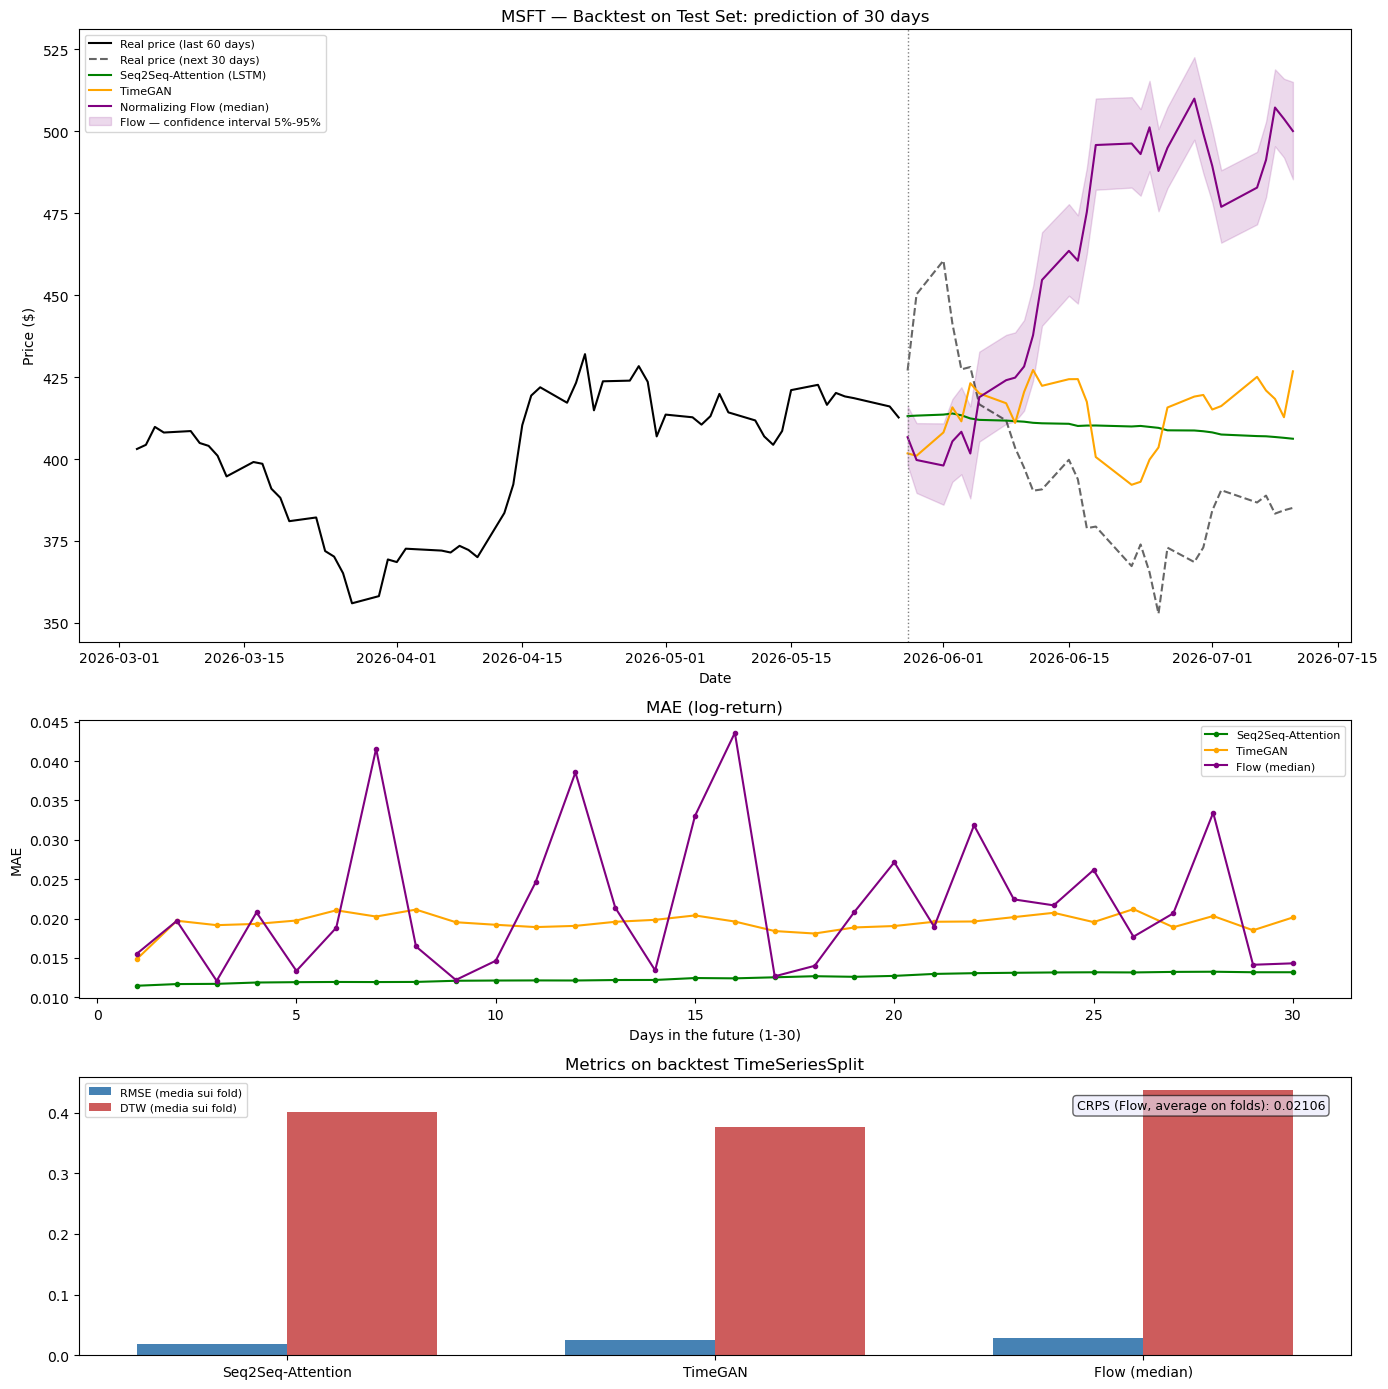

In [20]:
# Plot
fig = plt.figure(figsize=(14, 14))
gs = fig.add_gridspec(3, 1, height_ratios=[2.2, 1, 1])

# Subplot 1: price + prediction 
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history_dates, history_prices, color='black', label='Real price (last 60 days)')
ax1.plot(future_dates, actual_future_prices, color='black', linestyle='--', alpha=0.6,
          label='Real price (next 30 days)')
ax1.plot(future_dates, price_seq2seq, color='green', label='Seq2Seq-Attention (LSTM)')
ax1.plot(future_dates, price_timegan, color='orange', label='TimeGAN')
ax1.plot(future_dates, price_flow_median, color='purple', label='Normalizing Flow (median)')
ax1.fill_between(future_dates, price_flow_lower, price_flow_upper, color='purple', alpha=0.15,
                  label='Flow — confidence interval 5%-95%')
ax1.axvline(future_dates[0], color='gray', linestyle=':', linewidth=1)
ax1.set_title(f"{TICKER} — Backtest on Test Set: prediction of {HORIZON} days")
ax1.set_xlabel('Date')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left', fontsize=8)

# Subplot 2: MAE 
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(days_ahead, mae_per_day_seq2seq, color='green', marker='o', markersize=3, label='Seq2Seq-Attention')
ax2.plot(days_ahead, mae_per_day_timegan, color='orange', marker='o', markersize=3, label='TimeGAN')
ax2.plot(days_ahead, mae_per_day_flow, color='purple', marker='o', markersize=3, label='Flow (median)')
ax2.set_title('MAE (log-return)')
ax2.set_xlabel('Days in the future (1-30)')
ax2.set_ylabel('MAE')
ax2.legend(fontsize=8)

# Subplot 3: metrics on backtest TimeSeriesSplit
ax3 = fig.add_subplot(gs[2, 0])
models_names = ['Seq2Seq-Attention', 'TimeGAN', 'Flow (median)']
rmse_vals = [summary_df.loc['RMSE_Seq2Seq'].item(), summary_df.loc['RMSE_TimeGAN'].item(), summary_df.loc['RMSE_Flow_median'].item()]
dtw_vals = [summary_df.loc['DTW_Seq2Seq'].item(), summary_df.loc['DTW_TimeGAN'].item(), summary_df.loc['DTW_Flow_median'].item()]

x = np.arange(len(models_names))
width = 0.35
ax3.bar(x - width/2, rmse_vals, width, color='steelblue', label='RMSE (media sui fold)')
ax3.bar(x + width/2, dtw_vals, width, color='indianred', label='DTW (media sui fold)')
ax3.set_xticks(x)
ax3.set_xticklabels(models_names)
ax3.set_title('Metrics on backtest TimeSeriesSplit')
ax3.legend(fontsize=8)

crps_val = summary_df.loc['CRPS_Flow'].item()
ax3.text(0.98, 0.92, f"CRPS (Flow, average on folds): {crps_val:.5f}", transform=ax3.transAxes,
          ha='right', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.6))

plt.tight_layout()
plt.show